Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Train R²: 0.9997
Test  R²: 0.9994
R² Gap (Train - Test): 0.0002
Train RMSE: 3.9967
Test  RMSE: 5.5115
RMSE Gap (Test - Train): 1.5148


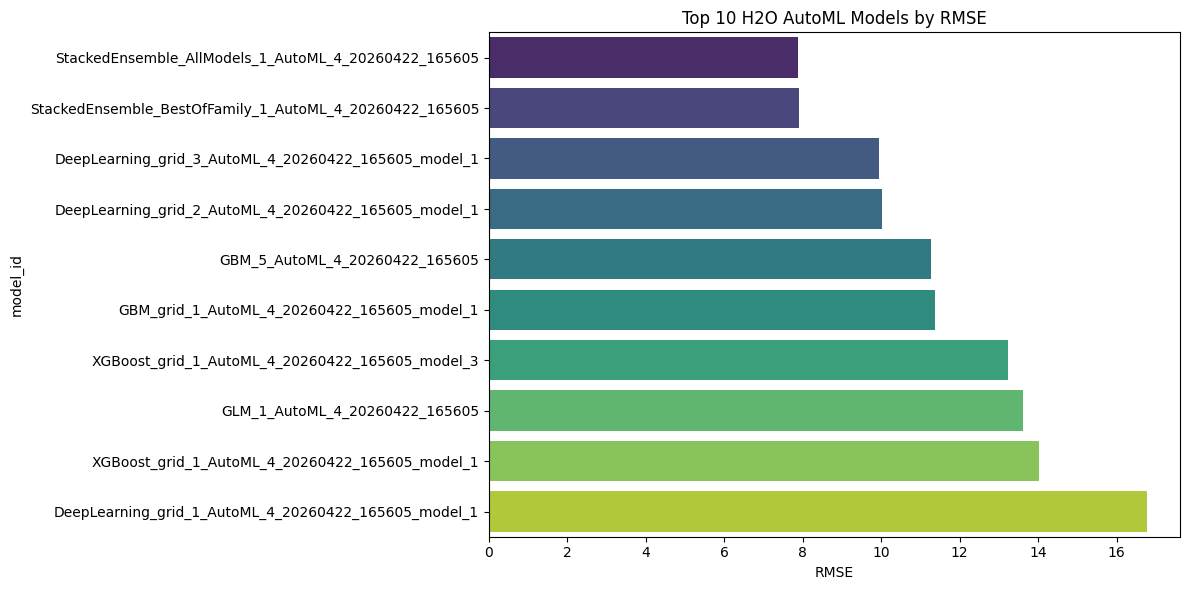

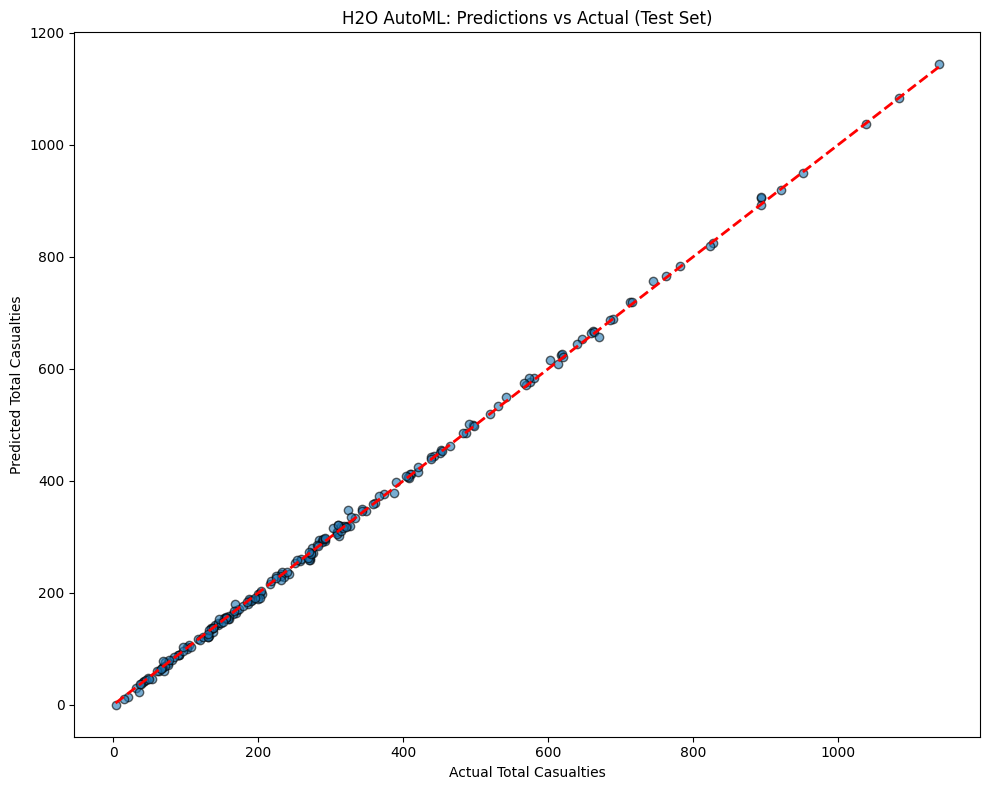

In [7]:
import subprocess
import sys
try:
    import h2o
    from h2o.automl import H2OAutoML
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "h2o"])
    import h2o
    from h2o.automl import H2OAutoML

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Augmented Dataset of Nigeria Crash.csv')
drop_cols = ['Quarter', 'State', 'Quarter_Date', 'State_Encoded']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
state_dummies = [c for c in df.columns if c.startswith('State_')]
df.drop(columns=state_dummies, inplace=True)
df = df.select_dtypes(include=[np.number])
df.dropna(inplace=True)
target = 'Total_Casualties'
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)
h2o.init(max_mem_size='4G', nthreads=2, verbose=False)
train_h2o = h2o.H2OFrame(train_df)
test_h2o = h2o.H2OFrame(test_df)
train_h2o[target] = train_h2o[target].asnumeric()
test_h2o[target] = test_h2o[target].asnumeric()
aml = H2OAutoML(max_models=20, seed=42, verbosity=None, nfolds=5, sort_metric='RMSE')
aml.train(x=X.columns.tolist(), y=target, training_frame=train_h2o)
leader = aml.leader
pred_train = leader.predict(train_h2o).as_data_frame().values.flatten()
pred_test = leader.predict(test_h2o).as_data_frame().values.flatten()
train_r2 = r2_score(y_train, pred_train)
test_r2 = r2_score(y_test, pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
gap_r2 = train_r2 - test_r2
gap_rmse = test_rmse - train_rmse
print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")
print(f"R² Gap (Train - Test): {gap_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")
print(f"RMSE Gap (Test - Train): {gap_rmse:.4f}")
lb = aml.leaderboard.as_data_frame()
lb = lb.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=lb, x='rmse', y='model_id', palette='viridis')
plt.xlabel('RMSE')
plt.title('Top 10 H2O AutoML Models by RMSE')
plt.tight_layout()
plt.savefig('h2o_automl_leaderboard.png', dpi=150)
plt.show()
plt.figure(figsize=(10, 8))
plt.scatter(y_test, pred_test, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Total Casualties')
plt.ylabel('Predicted Total Casualties')
plt.title('H2O AutoML: Predictions vs Actual (Test Set)')
plt.tight_layout()
plt.savefig('h2o_automl_predictions.png', dpi=150)
plt.show()
try:
    varimp = leader.varimp(use_pandas=True)
    if varimp is not None and len(varimp) > 0:
        varimp = varimp.sort_values('variable_importance', ascending=False)
        plt.figure(figsize=(10, 8))
        sns.barplot(data=varimp.head(20), x='variable_importance', y='variable', palette='rocket')
        plt.title('Top 20 Feature Importances (H2O AutoML Leader)')
        plt.tight_layout()
        plt.savefig('h2o_automl_feature_importance.png', dpi=150)
        plt.show()
except:
    pass
h2o.cluster().shutdown()